In [ ]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,ConfusionMatrixDisplay, roc_curve)

In [ ]:
files.upload()

Saving Pakistani_Diabetes_Dataset.csv to Pakistani_Diabetes_Dataset.csv


{'Pakistani_Diabetes_Dataset.csv': b'Age,Gender,Rgn ,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome\r\n60,1,0,76,29.9,41,130,90,0,8.9,278,0,30,1,0,5,0,60,1\r\n57,1,1,64,24.3,39,120,80,1,8.5,165,0,20,1,1,20,0,42,1\r\n58,0,0,73,25.2,34,140,90,0,5.65,130,1,20,0,0,0,0,54,0\r\n27,0,1,60,22.01,30,110,70,0,5,95,0,15,0,0,0,0,57,0\r\n56,1,0,70,25.8,43,125,90,0,8.3,139,1,40,1,0,5,1,53,1\r\n45,1,1,79,30.2,39,125,85,1,9.3,238,1,10,1,1,10,0,59,1\r\n50,1,0,74,28,38,150,90,0,8.45,374,1,20,1,1,4,0,53,1\r\n56,1,1,56,27,40,140,90,1,9.4,338,0,30,0,1,10,0,44,1\r\n45,1,0,84,27.82,39,110,85,1,6.7,290,1,0,1,1,3,0,40,1\r\n57,0,0,83,27.2,45,145,80,1,10,172,1,0,1,0,10,1,43,1\r\n45,0,0,89,32.1,43,184,100,0,11.7,270,0,20,1,1,8,0,40,1\r\n48,1,0,58,23.38,37,110,80,1,8.2,175,0,30,0,0,4,0,37,1\r\n46,1,0,68,28.5,39.5,135,75,0,7.8,104,1,20,1,0,3,0,35,1\r\n35,1,0,77,32.15,41,115,85,1,8,464,1,20,1,1,15,0,39,1\r\n60,1,0,69,27.3,39,175,95,1,7.5,272,1,25,1,0,9,0,41,1\r\n55,1,0,65,26.2,42,150,10

In [ ]:
df = pd.read_csv('Pakistani_Diabetes_Dataset.csv')
df.head()

,Age,Gender,Rgn,wt,BMI,wst,sys,dia,his,A1c,B.S.R,vision,Exr,dipsia,uria,Dur,neph,HDL,Outcome
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1


In [ ]:
df.columns

Index(['Age', 'Gender', 'Region', 'Weight_kg', 'BMI', 'Waist_cm',
       'Systolic_BP', 'Diastolic_BP', 'Family_History', 'A1C',
       'Random_Glucose', 'Blurred_Vision', 'Exercise_Minutes', 'Polydipsia',
       'Polyuria', 'Duration_Years', 'Nephropathy', 'HDL', 'Outcome'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()  # fixes 'Rgn ' -> 'Rgn'

df = df.rename(columns={
    'Age': 'Age',
    'Gender': 'Gender',
    'Rgn': 'Region',
    'wt': 'Weight_kg',
    'BMI': 'BMI',
    'wst': 'Waist_cm',
    'sys': 'Systolic_BP',
    'dia': 'Diastolic_BP',
    'his': 'Family_History',
    'A1c': 'A1C',
    'B.S.R': 'Random_Glucose',
    'vision': 'Blurred_Vision',
    'Exr': 'Exercise_Minutes',
    'dipsia': 'Polydipsia',
    'uria': 'Polyuria',
    'Dur': 'Duration_Years',
    'neph': 'Nephropathy',
    'HDL': 'HDL',
    'Outcome': 'Outcome'
})

print(df.columns)

Index(['Age', 'Gender', 'Region', 'Weight_kg', 'BMI', 'Waist_cm',
       'Systolic_BP', 'Diastolic_BP', 'Family_History', 'A1C',
       'Random_Glucose', 'Blurred_Vision', 'Exercise_Minutes', 'Polydipsia',
       'Polyuria', 'Duration_Years', 'Nephropathy', 'HDL', 'Outcome'],
      dtype='object')


In [ ]:
import pandas as pd

# ============================================================
# 1. AGE GROUPING (safe — no leakage, legitimate risk factor)
# ============================================================
age_bins   = [0, 20, 30, 40, 50, 60, 120]
age_labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)


# ============================================================
# 2. BMI CATEGORY — using standard WHO cutoffs
# (swap to the Asian-population cutoffs below ONLY if your
# dataset is explicitly Asian-population survey data — WHO
# standard is <18.5 / <25 / <30, not <23/<25/<30)
# ============================================================
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].clip(10, 70).apply(bmi_category)

# If you specifically need Asian-population cutoffs, use this instead:
# def bmi_category_asian(bmi):
#     if bmi < 18.5: return 'Underweight'
#     elif bmi < 23: return 'Normal'
#     elif bmi < 25: return 'Overweight (At Risk)'
#     elif bmi < 30: return 'Obese I'
#     else: return 'Obese II'
# df['BMI_Category'] = df['BMI'].clip(10, 70).apply(bmi_category_asian)


# ============================================================
# 3. BLOOD PRESSURE CATEGORY — corrected to proper AHA staging
# (previous version used OR logic for Stage 1, which misclassifies)
# ============================================================
def bp_category(row):
    s, d = row['Systolic_BP'], row['Diastolic_BP']
    if s > 180 or d > 120:
        return 'Hypertensive Crisis'
    elif s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    elif (120 <= s < 140) or (80 <= d < 90):
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

df['BP_Category'] = df.apply(bp_category, axis=1)


# ============================================================
# 4. A1C / GLUCOSE CATEGORIES — DISPLAY-ONLY, NOT MODEL FEATURES
# These use the actual clinical diagnostic thresholds for diabetes.
# Keep them for dashboard visuals (e.g. "% of patients in diabetic
# A1C range") but DO NOT feed them, or the raw A1C/Random_Glucose
# columns, into the classifier — check first whether `Outcome` was
# derived from these values in the original dataset. If so, this
# is textbook data leakage.
# ============================================================
df['A1C_Category'] = df['A1C'].apply(
    lambda x: 'Normal' if x < 5.7 else 'Prediabetes' if x < 6.5 else 'Diabetes Range'
)
df['Glucose_Category'] = df['Random_Glucose'].apply(
    lambda x: 'Normal' if x < 140 else 'Prediabetes' if x < 200 else 'Diabetes Range'
)


# ============================================================
# 5. DURATION + SYMPTOM BURDEN (safe, legitimate features)
# ============================================================
df['Duration_Band'] = pd.cut(
    df['Duration_Years'], bins=[-0.01, 0.99, 5, 10, 100],
    labels=['<1 yr', '1-5 yrs', '5-10 yrs', '10+ yrs']
)
df['Symptom_Burden'] = df[['Blurred_Vision', 'Polydipsia', 'Polyuria']].sum(axis=1)


# ============================================================
# 6. CATEGORICAL LABEL MAPPINGS (for dashboard readability)
# ============================================================
mappings = {
    'Gender':           {0: 'Male', 1: 'Female'},
    'Region':           {0: 'Rural', 1: 'Urban'},
    'Family_History':   {0: 'No', 1: 'Yes'},
    'Blurred_Vision':   {0: 'No', 1: 'Yes'},
    'Polydipsia':       {0: 'No', 1: 'Yes'},
    'Polyuria':         {0: 'No', 1: 'Yes'},
    'Nephropathy':      {0: 'No', 1: 'Yes'},
    'Outcome':          {0: 'Non-Diabetic', 1: 'Diabetic'},
}
for col, map_dict in mappings.items():
    df[f'{col}_Label'] = df[col].map(map_dict)


In [ ]:
df.duplicated().sum()
print('Shape before drop duplicates : ', df.shape)
df.drop_duplicates(inplace=True)
print('Shape After drop duplicates : ', df.shape)


Shape before drop duplicates :  (912, 34)
Shape After drop duplicates :  (910, 34)


In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,Age,Gender,Region,Weight_kg,BMI,Waist_cm,Systolic_BP,Diastolic_BP,Family_History,A1C,Random_Glucose,Blurred_Vision,Exercise_Minutes,Polydipsia,Polyuria,Duration_Years,Nephropathy,HDL,Outcome,Age_Group,BMI_Category,BP_Category,A1C_Category,Glucose_Category,Duration_Band,Symptom_Burden,Gender_Label,Region_Label,Family_History_Label,Blurred_Vision_Label,Polydipsia_Label,Polyuria_Label,Nephropathy_Label,Outcome_Label
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1,60+,Overweight,Hypertension Stage 1,Diabetes Range,Diabetes Range,1-5 yrs,1,Female,Rural,No,No,Yes,No,No,Diabetic
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1,50-59,Normal,Hypertension Stage 1,Diabetes Range,Prediabetes,10+ yrs,2,Female,Urban,Yes,No,Yes,Yes,No,Diabetic
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0,50-59,Overweight,Hypertension Stage 2,Normal,Normal,<1 yr,1,Male,Rural,No,Yes,No,No,No,Non-Diabetic
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0,20-29,Normal,Normal,Normal,Normal,<1 yr,0,Male,Urban,No,No,No,No,No,Non-Diabetic
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1,50-59,Overweight,Hypertension Stage 1,Diabetes Range,Normal,1-5 yrs,2,Female,Rural,No,Yes,Yes,No,Yes,Diabetic


In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
1,486
0,424


In [ ]:
region_check = df.groupby('Region')['Outcome'].agg(['mean', 'count'])
region_check.columns = ['Diabetic_Rate', 'N']
print(region_check)

        Diabetic_Rate    N
Region                    
0            0.533230  647
1            0.536122  263


In [ ]:
df.columns

Index(['Age', 'Gender', 'Region', 'Weight_kg', 'BMI', 'Waist_cm',
       'Systolic_BP', 'Diastolic_BP', 'Family_History', 'A1C',
       'Random_Glucose', 'Blurred_Vision', 'Exercise_Minutes', 'Polydipsia',
       'Polyuria', 'Duration_Years', 'Nephropathy', 'HDL', 'Outcome',
       'Age_Group', 'BMI_Category', 'BP_Category', 'A1C_Category',
       'Glucose_Category', 'Duration_Band', 'Symptom_Burden', 'Gender_Label',
       'Region_Label', 'Family_History_Label', 'Blurred_Vision_Label',
       'Polydipsia_Label', 'Polyuria_Label', 'Nephropathy_Label',
       'Outcome_Label'],
      dtype='object')

In [ ]:
gender_check = df.groupby('Gender')[['Weight_kg', 'BMI', 'HDL', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP']].mean()
print(gender_check)

gender_outcome = df.groupby('Gender')['Outcome'].agg(['mean', 'count'])
gender_outcome.columns = ['Diabetic_Rate', 'N']
print(gender_outcome)

        Weight_kg        BMI        HDL   Waist_cm  Systolic_BP  Diastolic_BP
Gender                                                                       
0       73.609337  24.436747  46.970516  35.236536   128.530713     80.896806
1       65.938767  26.600239  45.105368  35.660497   130.560636     83.530815
        Diabetic_Rate    N
Gender                    
0            0.356265  407
1            0.677932  503


In [ ]:
df.head()

,Age,Gender,Region,Weight_kg,BMI,Waist_cm,Systolic_BP,Diastolic_BP,Family_History,A1C,Random_Glucose,Blurred_Vision,Exercise_Minutes,Polydipsia,Polyuria,Duration_Years,Nephropathy,HDL,Outcome,Age_Group,BMI_Category,BP_Category,A1C_Category,Glucose_Category,Duration_Band,Symptom_Burden,Gender_Label,Region_Label,Family_History_Label,Blurred_Vision_Label,Polydipsia_Label,Polyuria_Label,Nephropathy_Label,Outcome_Label
0,60.0,1,0,76.0,29.90,41.0,130,90,0,8.90,278,0,30,1,0,5.0,0,60,1,60+,Overweight,Hypertension Stage 1,Diabetes Range,Diabetes Range,1-5 yrs,1,Female,Rural,No,No,Yes,No,No,Diabetic
1,57.0,1,1,64.0,24.30,39.0,120,80,1,8.50,165,0,20,1,1,20.0,0,42,1,50-59,Normal,Hypertension Stage 1,Diabetes Range,Prediabetes,10+ yrs,2,Female,Urban,Yes,No,Yes,Yes,No,Diabetic
2,58.0,0,0,73.0,25.20,34.0,140,90,0,5.65,130,1,20,0,0,0.0,0,54,0,50-59,Overweight,Hypertension Stage 2,Normal,Normal,<1 yr,1,Male,Rural,No,Yes,No,No,No,Non-Diabetic
3,27.0,0,1,60.0,22.01,30.0,110,70,0,5.00,95,0,15,0,0,0.0,0,57,0,20-29,Normal,Normal,Normal,Normal,<1 yr,0,Male,Urban,No,No,No,No,No,Non-Diabetic
4,56.0,1,0,70.0,25.80,43.0,125,90,0,8.30,139,1,40,1,0,5.0,1,53,1,50-59,Overweight,Hypertension Stage 1,Diabetes Range,Normal,1-5 yrs,2,Female,Rural,No,Yes,Yes,No,Yes,Diabetic


In [ ]:
# Data for dashboard
final_cols = [
    # Continuous / numeric — keep for calculations, KPI cards, averages
    'Age', 'Weight_kg', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP',
    'A1C', 'Random_Glucose', 'Exercise_Minutes', 'Duration_Years', 'HDL',
    'Symptom_Burden',

    # Categorical labels — for filters, slicers, grouped visuals
    'Age_Group', 'Gender_Label', 'Region_Label', 'BMI_Category',
    'BP_Category', 'A1C_Category', 'Glucose_Category', 'Duration_Band',
    'Family_History_Label', 'Blurred_Vision_Label', 'Polydipsia_Label',
    'Polyuria_Label', 'Nephropathy_Label', 'Outcome_Label'
]

df_final = df[final_cols]

In [ ]:
df_final.to_csv('cleaned_diabetes_dataset.csv', index=False)
files.download('cleaned_diabetes_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_final.columns

Index(['Age', 'Weight_kg', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP',
       'A1C', 'Random_Glucose', 'Exercise_Minutes', 'Duration_Years', 'HDL',
       'Symptom_Burden', 'Age_Group', 'Gender_Label', 'Region_Label',
       'BMI_Category', 'BP_Category', 'A1C_Category', 'Glucose_Category',
       'Duration_Band', 'Family_History_Label', 'Blurred_Vision_Label',
       'Polydipsia_Label', 'Polyuria_Label', 'Nephropathy_Label',
       'Outcome_Label'],
      dtype='object')

## EDA - Exploratory Data Analysis

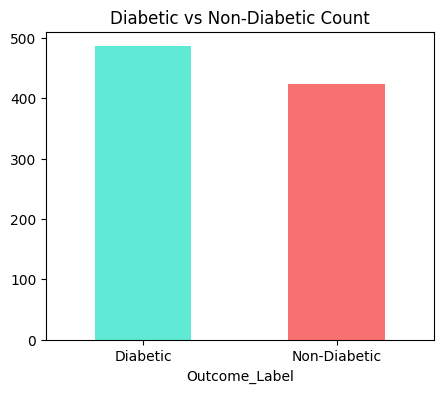

In [ ]:
# 1. Outcome distribution
plt.figure(figsize=(5,4))
df['Outcome_Label'].value_counts().plot(kind='bar', color=['#5EEAD4','#F87171'])
plt.title('Diabetic vs Non-Diabetic Count')
plt.xticks(rotation=0)
plt.show()

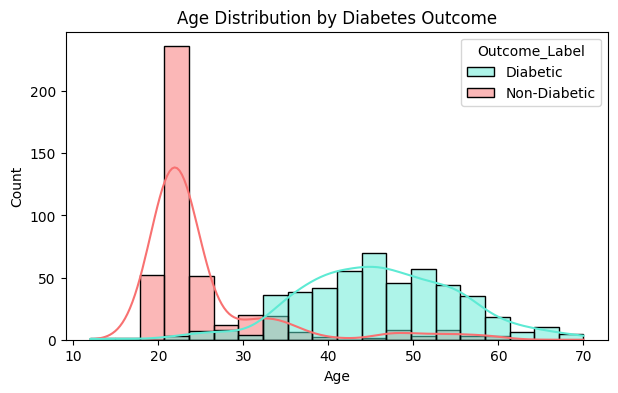

In [ ]:
# 2. Age distribution split by outcome
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='Age', hue='Outcome_Label', bins=20, kde=True, palette=['#5EEAD4','#F87171'])
plt.title('Age Distribution by Diabetes Outcome')
plt.show()


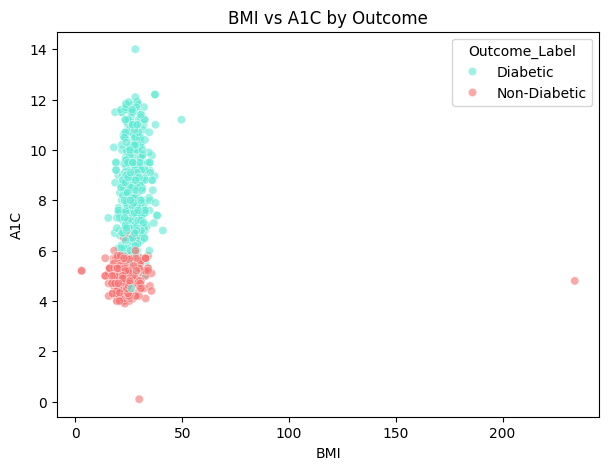

In [ ]:
# 3. BMI vs A1C scatter, colored by outcome
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='BMI', y='A1C', hue='Outcome_Label', palette=['#5EEAD4','#F87171'], alpha=0.6)
plt.title('BMI vs A1C by Outcome')
plt.show()

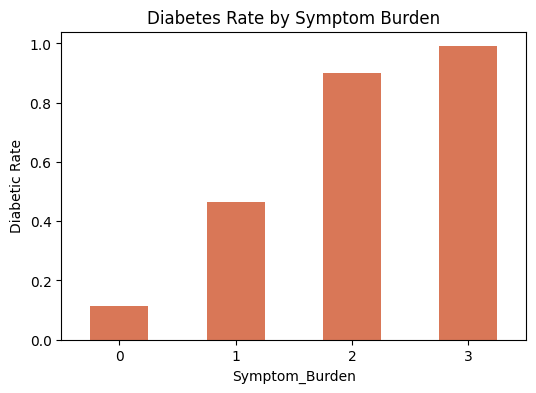

In [ ]:
# 4. Diabetes rate by symptom burden (bar)
symptom_rate = df.groupby('Symptom_Burden')['Outcome'].mean()
plt.figure(figsize=(6,4))
symptom_rate.plot(kind='bar', color='#D97757')
plt.title('Diabetes Rate by Symptom Burden')
plt.ylabel('Diabetic Rate')
plt.xticks(rotation=0)
plt.show()

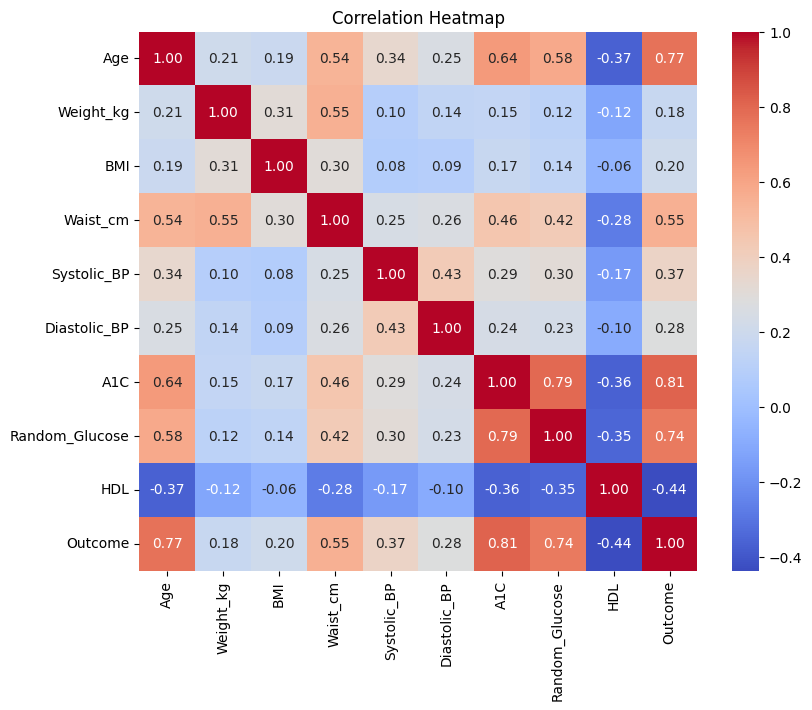

In [ ]:
# 5. Correlation heatmap of numeric features
plt.figure(figsize=(9,7))
numeric_cols = ['Age','Weight_kg','BMI','Waist_cm','Systolic_BP','Diastolic_BP','A1C','Random_Glucose','HDL','Outcome']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

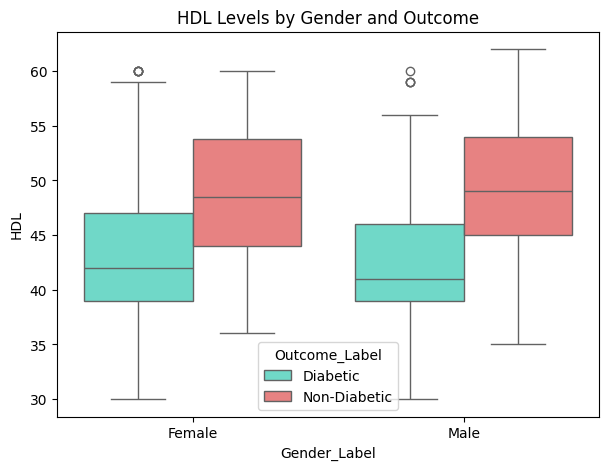

In [ ]:
# 6. Boxplot: HDL by Gender and Outcome
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Gender_Label', y='HDL', hue='Outcome_Label', palette=['#5EEAD4','#F87171'])
plt.title('HDL Levels by Gender and Outcome')
plt.show()

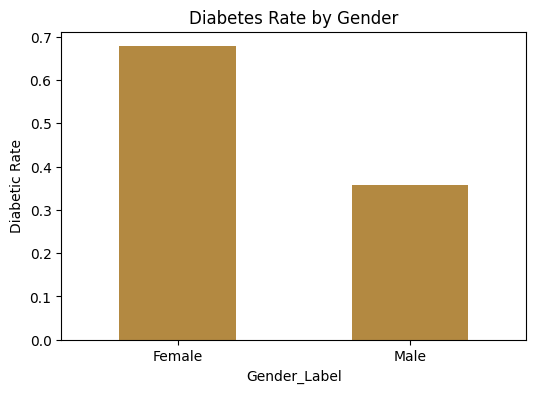

In [ ]:
# 7. Diabetes rate by symptom burden (bar)
symptom_rate = df.groupby('Gender_Label')['Outcome'].mean()
plt.figure(figsize=(6,4))
symptom_rate.plot(kind='bar', color='#B38941')
plt.title('Diabetes Rate by Gender')
plt.ylabel('Diabetic Rate')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# feature_cols = [
#     'Age', 'Weight_kg', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP',
#     'A1C', 'Random_Glucose', 'Exercise_Minutes', 'Duration_Years', 'HDL',
#     'Gender_Label', 'Region_Label', 'Family_History_Label',
#     'Blurred_Vision_Label', 'Polydipsia_Label', 'Polyuria_Label', 'Nephropathy_Label'
# ]



feature_cols_no_leakage = [
    'Age', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP',
    'HDL', 'Exercise_Minutes',
    'Gender_Label', 'Region_Label', 'Family_History_Label',
    'Blurred_Vision_Label', 'Polydipsia_Label', 'Polyuria_Label', 'Nephropathy_Label'
]

X = df[feature_cols_no_leakage]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X = df[feature_cols_no_leakage]
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X.head()

,Age,BMI,Waist_cm,Systolic_BP,Diastolic_BP,HDL,Exercise_Minutes,Gender_Label,Region_Label,Family_History_Label,Blurred_Vision_Label,Polydipsia_Label,Polyuria_Label,Nephropathy_Label
0,60.0,29.90,41.0,130,90,60,30,Female,Rural,No,No,Yes,No,No
1,57.0,24.30,39.0,120,80,42,20,Female,Urban,Yes,No,Yes,Yes,No
2,58.0,25.20,34.0,140,90,54,20,Male,Rural,No,Yes,No,No,No
3,27.0,22.01,30.0,110,70,57,15,Male,Urban,No,No,No,No,No
4,56.0,25.80,43.0,125,90,53,40,Female,Rural,No,Yes,Yes,No,Yes


In [ ]:
X['Exercise_Minutes'].value_counts()

,count
Exercise_Minutes,
0,414
30,153
20,151
25,58
15,58
45,22
40,17
10,11
35,11


In [ ]:
X.columns

Index(['Age', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP', 'HDL',
       'Exercise_Minutes', 'Gender_Label', 'Region_Label',
       'Family_History_Label', 'Blurred_Vision_Label', 'Polydipsia_Label',
       'Polyuria_Label', 'Nephropathy_Label'],
      dtype='object')

In [ ]:
numeric_features = [
    'Age', 'BMI', 'Waist_cm', 'Systolic_BP', 'Diastolic_BP',
    'Exercise_Minutes', 'HDL'
]

categorical_features = [
    'Gender_Label', 'Region_Label', 'Family_History_Label',
    'Blurred_Vision_Label', 'Polydipsia_Label', 'Polyuria_Label', 'Nephropathy_Label'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ("encode" , OrdinalEncoder(dtype=int), categorical_features),
    ],
    remainder='passthrough'
)

In [ ]:
pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

pipeline_mlp = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=500, random_state=42))
])

pipeline_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

In [ ]:

models = {
    "Logistic Regression": pipeline_logreg,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb,
    "MLP Neural Net": pipeline_mlp,
    "SVC": pipeline_svc,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = {}

for name, pipeline in models.items():
    print(f"Running cross-validation: {name}...")
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

Running cross-validation: Logistic Regression...
Running cross-validation: Random Forest...
Running cross-validation: XGBoost...
Running cross-validation: MLP Neural Net...
Running cross-validation: SVC...


In [ ]:
results_df = pd.DataFrame(cv_results).T.sort_values("f1", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1
MLP Neural Net,0.9547,0.9550,0.9615,0.9579
Random Forest,0.9533,0.9569,0.9563,0.9564
SVC,0.9478,0.9382,0.9666,0.9519
Logistic Regression,0.9450,0.9454,0.9538,0.9490
XGBoost,0.9423,0.9515,0.9409,0.9459


In [ ]:
best_model = pipeline_svc
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_train)

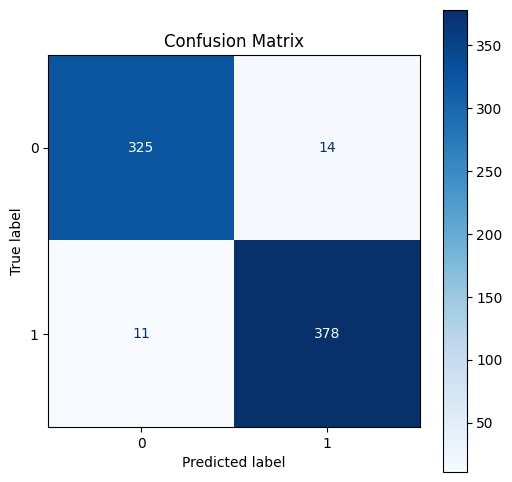

In [ ]:
cm = confusion_matrix(y_train, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_pred_test = best_model.predict(X_test)

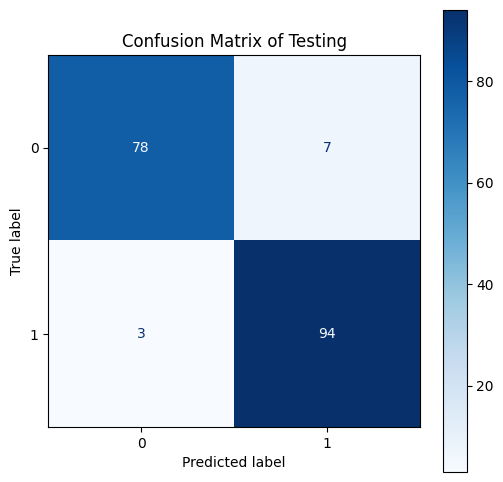

In [ ]:

cm = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix of Testing")
plt.show()

In [ ]:
# Check if Outcome perfectly matches the diagnostic categories
print(pd.crosstab(df['A1C_Category'], df['Outcome']))
print('\n')
print(pd.crosstab(df['Glucose_Category'], df['Outcome']))

Outcome           0    1
A1C_Category            
Diabetes Range    3  441
Normal          383   14
Prediabetes      38   31


Outcome             0    1
Glucose_Category          
Diabetes Range      0  269
Normal            422   55
Prediabetes         2  162


In [ ]:
pd.crosstab(df['Duration_Years'] > 0, df['Outcome'])

Outcome,0,1
Duration_Years,,
False,424,11
True,0,475


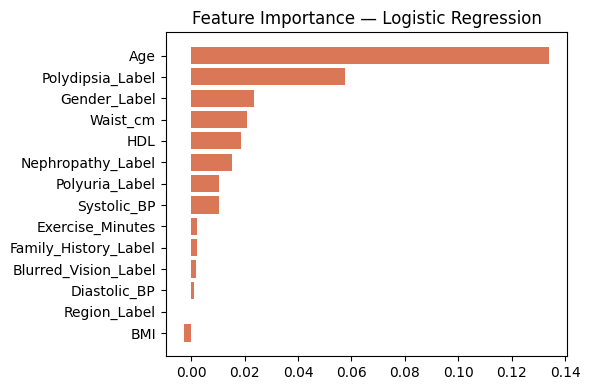

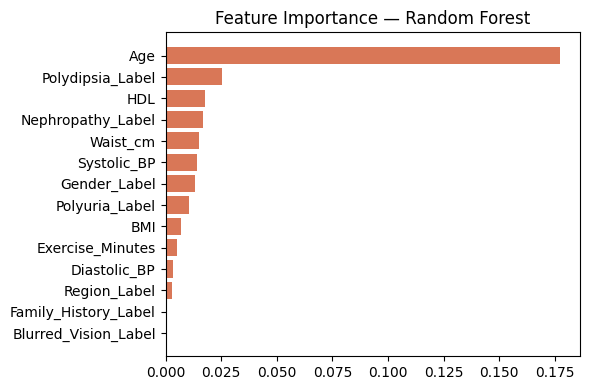

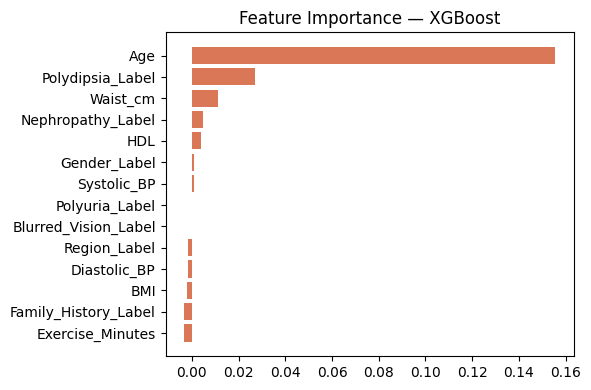

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


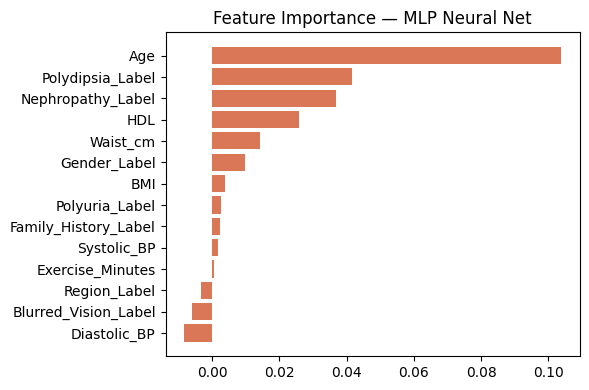

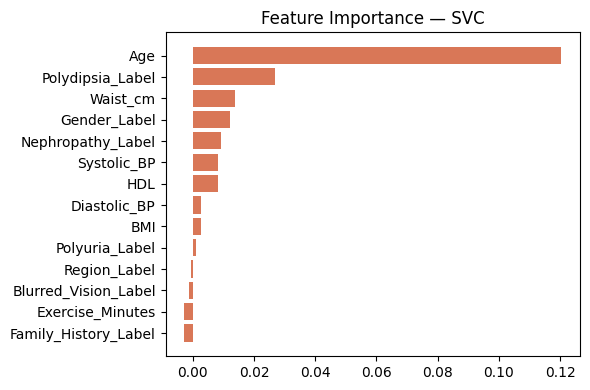

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

feature_names = X.columns  # since preprocessor keeps binary/categorical as-is with drop='if_binary'

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean}).sort_values('Importance')

    plt.figure(figsize=(6, 4))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color='#D97757')
    plt.title(f'Feature Importance — {name}')
    plt.tight_layout()
    plt.show()

## Feature Pruning

In [ ]:
feature_cols_pruned = [
    'Age', 'BMI', 'Waist_cm', 'Systolic_BP', 'Exercise_Minutes',
    'Gender_Label', 'Family_History_Label', 'Polydipsia_Label', 'Polyuria_Label'
]

X = df[feature_cols_pruned]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['Age', 'BMI', 'Waist_cm', 'Systolic_BP', 'Exercise_Minutes']
categorical_features = ['Gender_Label', 'Family_History_Label', 'Polydipsia_Label', 'Polyuria_Label']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ("encode" , OrdinalEncoder(dtype=int), categorical_features),
    ],
    remainder='passthrough'
)

In [ ]:
models = {
    "Logistic Regression": pipeline_logreg,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb,
    "MLP Neural Net": pipeline_mlp,
    "SVC": pipeline_svc,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = {}

for name, pipeline in models.items():
    print(f"Running cross-validation: {name}...")
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

Running cross-validation: Logistic Regression...
Running cross-validation: Random Forest...
Running cross-validation: XGBoost...
Running cross-validation: MLP Neural Net...


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

Running cross-validation: SVC...


In [ ]:
results_df = pd.DataFrame(cv_results).T.sort_values("f1", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1
SVC,0.9396,0.9244,0.9666,0.9448
MLP Neural Net,0.9382,0.9393,0.9460,0.9424
Random Forest,0.9368,0.9373,0.9460,0.9413
Logistic Regression,0.9340,0.9279,0.9512,0.9392
XGBoost,0.9313,0.9281,0.9461,0.9365


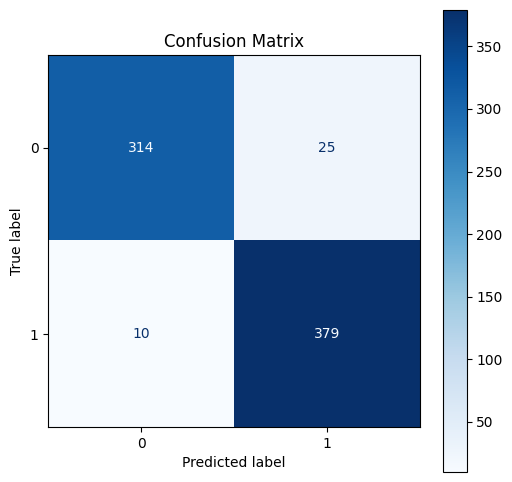

In [ ]:


best_model = pipeline_svc
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_train)

cm = confusion_matrix(y_train, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

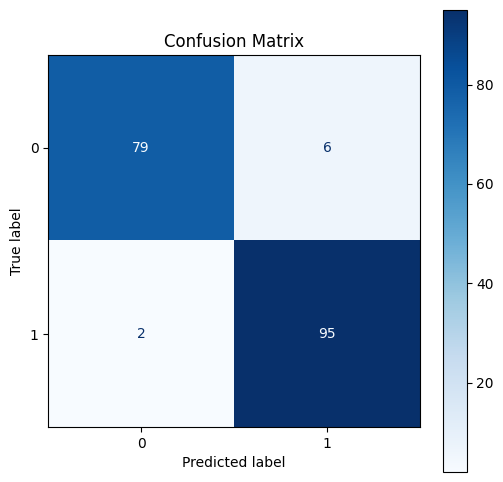

In [ ]:
y_pred_test = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

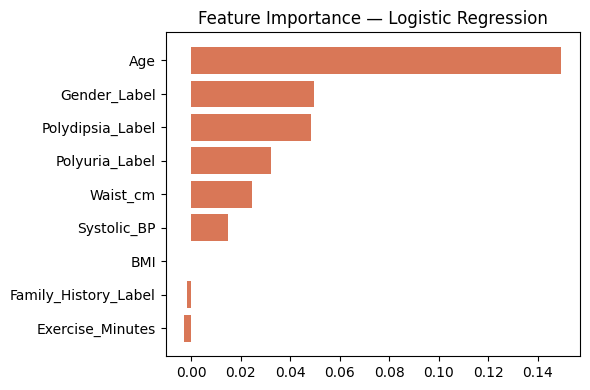

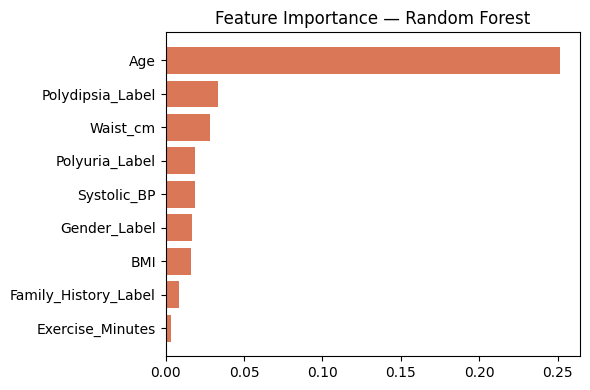

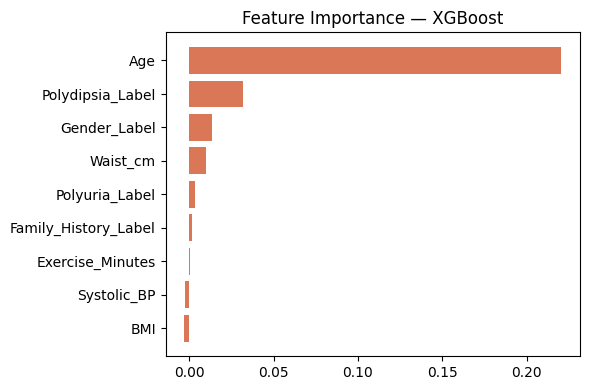

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


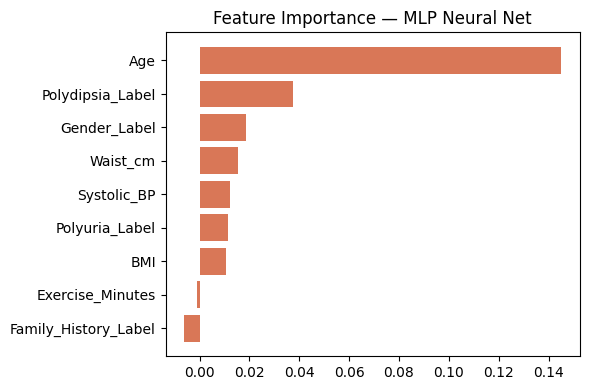

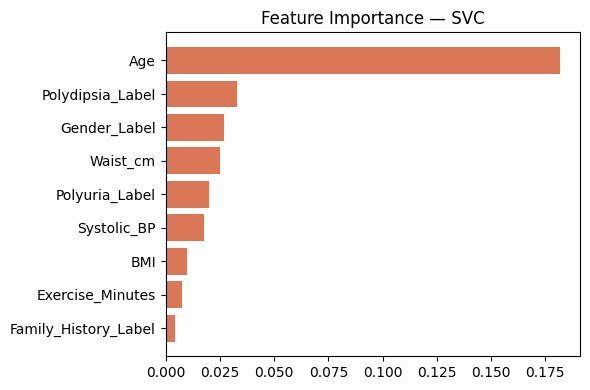

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

feature_names = X.columns

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean}).sort_values('Importance')

    plt.figure(figsize=(6, 4))
    plt.barh(imp_df['Feature'], imp_df['Importance'], color='#D97757')
    plt.title(f'Feature Importance — {name}')
    plt.tight_layout()
    plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "diabetes_model.joblib")
# files.download("diabetes_model.joblib")

['diabetes_model.joblib']